# 02 · Diagnóstico y retuning del realce por entidad

**Alcance:** entender por qué la **Config 5** (Híbrido + ontología + realce por entidad)
**empeora** respecto a la Config 4, y proponer una versión mejorada o su descarte para v1
(**punto 2** de la entrega).

## 1. Contexto y objetivos

En la escalera, el realce suave por entidad — `s_final = s_RRF · (1 + λ·1_entidad)` con
λ = 0.20 — bajó el nDCG@10 global de **0.936** (Config 4) a **0.911** (Config 5). El realce
pretende **subir** documentos cuya entidad coincide con la consulta, así que un deterioro
indica un problema de **diseño del indicador** o de **calibración de λ**. Objetivos:

1. Diagnosticar el mecanismo: ¿el indicador de entidad es **discriminativo** o se activa
   para demasiados documentos?
2. **Barrer λ** ∈ {0.05, 0.10, 0.15, 0.20, 0.30}.
3. Medir **precision/recall del detector** de entidad.
4. Proponer y evaluar un **realce mejorado**.
5. Recomendación clara: **mantener, modificar o descartar** en v1.

## 2. Preparación, datos y núcleo de recuperación

### Núcleo de recuperación (idéntico en todos los notebooks de la entrega)

Para que cada notebook sea **autónomo y reproducible**, se define aquí todo el código de recuperación y evaluación: librerías, carga de datos, métricas, índices (BM25 y denso), fusión RRF, detector de entidades, el motor de las cinco configuraciones y la estadística. No se importa nada de `experimentos/lib`.

In [1]:
# --- Librerías y utilidades base ---
import json, sys, time, math, re, unicodedata, warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy import stats as sp_stats

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.25})

# Localiza la raíz del proyecto y la carpeta de datos del experimento.
RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
EXP = RAIZ / "experimentos"
cfg = yaml.safe_load((EXP / "config.yaml").read_text(encoding="utf-8"))
SEMILLA = cfg["evaluacion"]["semilla"]
np.random.seed(SEMILLA)
print("Encoder:", cfg["encoder"]["tipo"], "→", cfg["encoder"]["modelo_st"])
print("BM25:", cfg["bm25"], "| RRF k =", cfg["fusion"]["k_rrf"], "| realce λ =", cfg["realce"]["lambda"])

Encoder: sentence-transformer → jinaai/jina-embeddings-v3
BM25: {'k1': 1.5, 'b': 0.75} | RRF k = 60 | realce λ = 0.2


In [2]:
# --- Carga de datos ya construidos por el pipeline reproducible (make all) ---
# El corpus lo produce experimentos/preprocess_corpus.py; las consultas y juicios,
# experimentos/generar_consultas.py (protocolo known-item). Aquí solo se leen.
def cargar_jsonl(ruta):
    return [json.loads(l) for l in Path(ruta).read_text(encoding="utf-8").splitlines() if l.strip()]

docs      = cargar_jsonl(EXP / cfg["rutas"]["corpus"])
consultas = cargar_jsonl(EXP / cfg["rutas"]["consultas"])
qrels     = {r["id"]: r["relevancia"] for r in cargar_jsonl(EXP / cfg["rutas"]["qrels"])}
ontologia = yaml.safe_load((EXP / cfg["rutas"]["ontologia"]).read_text(encoding="utf-8"))

tiene_gold = lambda q: any(g > 0 for g in q.values())
con_gold = [c for c in consultas if tiene_gold(qrels.get(c["id"], {}))]
estratos = sorted({c["estrato"] for c in consultas})
print(f"{len(docs)} documentos | {len(consultas)} consultas | {len(con_gold)} con gold")
print("Estratos:", {e: sum(1 for c in consultas if c['estrato']==e) for e in estratos})

17 documentos | 51 consultas | 40 con gold
Estratos: {'ambigua': 13, 'competencias': 11, 'documento_largo': 10, 'entidad_exacta': 17}


In [3]:
# --- Métricas de recuperación (nDCG, Recall, MRR, P@k, AP) con ganancia exponencial ---
def _grado(qrel, doc): return float(qrel.get(doc, 0.0))

def dcg(ranking, qrel, k):
    return sum((2.0**_grado(qrel, d) - 1.0) / math.log2(i + 1)
               for i, d in enumerate(ranking[:k], 1) if _grado(qrel, d) > 0)

def ndcg(ranking, qrel, k):
    ideal = sorted((g for g in qrel.values() if g > 0), reverse=True)
    idcg = sum((2.0**g - 1.0) / math.log2(i + 1) for i, g in enumerate(ideal[:k], 1))
    return 0.0 if idcg == 0 else dcg(ranking, qrel, k) / idcg

def recall(ranking, qrel, k):
    rel = {d for d, g in qrel.items() if g > 0}
    return 0.0 if not rel else sum(1 for d in ranking[:k] if d in rel) / len(rel)

def mrr(ranking, qrel, k):
    for i, d in enumerate(ranking[:k], 1):
        if _grado(qrel, d) > 0: return 1.0 / i
    return 0.0

def precision(ranking, qrel, k):
    return 0.0 if k == 0 else sum(1 for d in ranking[:k] if _grado(qrel, d) > 0) / k

def average_precision(ranking, qrel, k):
    rel = {d for d, g in qrel.items() if g > 0}
    if not rel: return 0.0
    ac, s = 0, 0.0
    for i, d in enumerate(ranking[:k], 1):
        if d in rel: ac += 1; s += ac / i
    return s / min(len(rel), k)

def metricas_consulta(rank, qrel):
    return {"ndcg@10": ndcg(rank, qrel, 10), "mrr@10": mrr(rank, qrel, 10),
            "recall@100": recall(rank, qrel, 100), "p@10": precision(rank, qrel, 10),
            "ap@100": average_precision(rank, qrel, 100)}

# auto-test mínimo
assert ndcg(["a","b"], {"a":1.0}, 10) == 1.0 and mrr(["b","a"], {"a":1.0}, 10) == 0.5
print("Métricas listas (auto-test OK).")

Métricas listas (auto-test OK).


In [4]:
# --- Núcleo de recuperación: BM25, codificador denso, RRF, detector y motor ---
_STOP = {"el","la","los","las","un","una","unos","unas","de","del","a","ante","con","en","para",
         "por","que","y","o","u","se","su","sus","lo","al","es","son","como","mas","pero","sin",
         "sobre","entre","cada","ya","cuando","donde","cual","quien","cuanto","muy","este","esta","estos"}

def tokenizar_es(texto):
    "Minúsculas, sin tildes, sin puntuación ni stopwords."
    texto = unicodedata.normalize("NFKD", texto.lower())
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return [t for t in re.findall(r"[a-z0-9]+", texto) if t not in _STOP and len(t) > 1]

class BM25Index:
    "BM25 clásico desde cero, con analizador en español."
    def __init__(self, k1=1.5, b=0.75): self.k1, self.b = k1, b
    def indexar(self, ids, textos):
        self._ids = list(ids); self._tf = [Counter(tokenizar_es(t)) for t in textos]
        self._len = [sum(c.values()) for c in self._tf]
        self._avg = (sum(self._len)/len(self._len)) if self._len else 0.0
        df = Counter()
        for c in self._tf: df.update(c.keys())
        n = len(self._tf); self._idf = {t: math.log(1+(n-d+0.5)/(d+0.5)) for t, d in df.items()}
        return self
    def buscar(self, q):
        qt = tokenizar_es(q); s = np.zeros(len(self._ids))
        for i, tf in enumerate(self._tf):
            acc = 0.0
            for t in qt:
                if t in tf:
                    f = tf[t]; den = f + self.k1*(1-self.b+self.b*self._len[i]/(self._avg or 1))
                    acc += self._idf.get(t, 0.0)*f*(self.k1+1)/den
            s[i] = acc
        return [(self._ids[i], float(s[i])) for i in np.argsort(-s)]

def _l2(m):
    n = np.linalg.norm(m, axis=1, keepdims=True); n[n == 0] = 1.0
    return m / n

class SentenceTransformerEncoder:
    "Codificador denso real (jina-embeddings-v3), congelado; solo inferencia."
    def __init__(self, modelo, truncar_dim=None):
        from transformers import PreTrainedModel
        if not hasattr(PreTrainedModel, "all_tied_weights_keys"):
            PreTrainedModel.all_tied_weights_keys = {}      # shim compat. transformers 5.x
        from sentence_transformers import SentenceTransformer
        self._m = SentenceTransformer(modelo, trust_remote_code=True)
        self._tr = truncar_dim
        self.nombre = modelo.split("/")[-1] + (f"-mrl{truncar_dim}" if truncar_dim else "")
        self.dim = truncar_dim or self._m.get_sentence_embedding_dimension()
    def encode(self, textos):
        v = self._m.encode(list(textos), convert_to_numpy=True, normalize_embeddings=False).astype(np.float32)
        if self._tr: v = v[:, :self._tr]
        return _l2(v)

class LSAEncoder:
    "Fallback offline determinista (TF-IDF + SVD) si el modelo real no está disponible."
    def __init__(self, n_comp=128, semilla=42):
        from sklearn.feature_extraction.text import TfidfVectorizer
        self.nombre = f"lsa-{n_comp}"; self._nc = n_comp; self._sem = semilla; self.dim = n_comp
        self._tfidf = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=1,
                                      sublinear_tf=True, strip_accents="unicode", lowercase=True)
        self._svd = None
    def fit(self, textos):
        from sklearn.decomposition import TruncatedSVD
        X = self._tfidf.fit_transform(textos)
        nc = max(min(self._nc, X.shape[1]-1, X.shape[0]-1), 2)
        self._svd = TruncatedSVD(n_components=nc, random_state=self._sem).fit(X); self.dim = nc
        return self
    def encode(self, textos):
        return _l2(self._svd.transform(self._tfidf.transform(textos)).astype(np.float32))

def construir_encoder(cfg, textos_fit):
    if cfg["encoder"]["tipo"] == "sentence-transformer":
        try:
            enc = SentenceTransformerEncoder(cfg["encoder"]["modelo_st"])
            print("Encoder real:", enc.nombre, "| dim", enc.dim); return enc
        except Exception as e:
            print("Modelo real no disponible (", type(e).__name__, ") → fallback LSA")
    enc = LSAEncoder(cfg["encoder"]["lsa_componentes"]).fit(textos_fit)
    print("Encoder LSA:", enc.nombre, "| dim", enc.dim); return enc

class DenseIndex:
    "Índice denso por coseno (producto interno sobre vectores normalizados)."
    def __init__(self, encoder): self.encoder = encoder
    def indexar(self, ids, textos):
        self._ids = list(ids); self._mat = self.encoder.encode(textos); return self
    def buscar(self, q):
        qv = self.encoder.encode([q])[0]; s = self._mat @ qv
        return [(self._ids[i], float(s[i])) for i in np.argsort(-s)]

def _norm(s):
    s = unicodedata.normalize("NFKD", s.lower())
    return "".join(c for c in s if not unicodedata.combining(c))

def rrf(a, b, k=60):
    "Reciprocal Rank Fusion con orden y desempate deterministas por doc_id."
    ra = {d: i+1 for i, (d, _) in enumerate(a)}; rb = {d: i+1 for i, (d, _) in enumerate(b)}
    ds = [d for d, _ in a] + [d for d, _ in b if d not in ra]; big = len(ds)+k+1
    fus = {d: 1.0/(k+ra.get(d, big)) + 1.0/(k+rb.get(d, big)) for d in ds}
    return sorted(ds, key=lambda d: (-fus[d], d)), fus

class DetectorEntidades:
    "Detecta clases de la ontología y nombres propios mencionados en la consulta."
    def __init__(self, ontologia):
        self._term = []
        for clase, cuerpo in ontologia.get("clases", {}).items():
            for t in [clase, *cuerpo.get("sinonimos", [])]:
                self._term.append((_norm(t), clase))
        self._pat = re.compile(r"\b[A-ZÁÉÍÓÚÑ][a-záéíóúñ]{2,}\b")
    def clases_en(self, q):
        cq = _norm(q); return {c for t, c in self._term if t and t in cq}
    def tiene_nombre_propio(self, q):
        toks = self._pat.findall(q)
        if not toks: return False
        primera = q.strip().split()[:1]
        cand = [t for t in toks if not (primera and t == primera[0])]
        return any(_norm(t) not in {tt for tt, _ in self._term} for t in cand)

CONFIGS = {1:"Denso puro", 2:"Denso + ontología", 3:"Híbrido (sin ontología)",
           4:"Híbrido + ontología", 5:"Híbrido + ontología + realce"}
NOMBRE_BM25 = "BM25 (referencia léxica)"; CONFIG_BM25 = 0

class MotorRecuperacion:
    "Construye los 6 índices una sola vez y responde cualquier configuración."
    def __init__(self, docs, encoder, ontologia, k1, b, k_rrf, lambda_realce):
        self.doc_ids = [d["id"] for d in docs]; self.k_rrf = k_rrf; self.lam = lambda_realce
        self.det = DetectorEntidades(ontologia)
        self.ent = {d["id"]: set(d["metadatos_ontologia"].get("entidades_principales", [])) for d in docs}
        self.esnp = {d["id"]: bool(d.get("nombre_propio_buscable", False)) for d in docs}
        desc = [d["descripcion"] for d in docs]; onto = [d["texto_indexable"] for d in docs]
        self.bm_desc = BM25Index(k1, b).indexar(self.doc_ids, desc)
        self.bm_onto = BM25Index(k1, b).indexar(self.doc_ids, onto)
        self.dn_desc = DenseIndex(encoder).indexar(self.doc_ids, desc)
        self.dn_onto = DenseIndex(encoder).indexar(self.doc_ids, onto)
    def indicador(self, q, doc_id):
        "1 si la consulta y el documento comparten entidad (o ambos son de nombre propio)."
        if self.det.clases_en(q) & self.ent.get(doc_id, set()): return 1
        if self.det.tiene_nombre_propio(q) and self.esnp.get(doc_id): return 1
        return 0
    def fusion_onto(self, q):
        "Devuelve (orden, dict de scores RRF) del híbrido+ontología (config 4)."
        return rrf(self.bm_onto.buscar(q), self.dn_onto.buscar(q), self.k_rrf)
    def recuperar(self, config, q):
        if config == CONFIG_BM25: return [d for d, _ in self.bm_desc.buscar(q)]
        if config == 1: return [d for d, _ in self.dn_desc.buscar(q)]
        if config == 2: return [d for d, _ in self.dn_onto.buscar(q)]
        if config == 3: return rrf(self.bm_desc.buscar(q), self.dn_desc.buscar(q), self.k_rrf)[0]
        if config == 4: return self.fusion_onto(q)[0]
        if config == 5:
            _, fus = self.fusion_onto(q)
            final = {d: s*(1 + self.lam*self.indicador(q, d)) for d, s in fus.items()}
            return sorted(final, key=lambda d: (-final[d], d))
        raise ValueError(config)

textos_fit = [d["texto_indexable"] for d in docs] + [d["descripcion"] for d in docs]
encoder = construir_encoder(cfg, textos_fit)
motor = MotorRecuperacion(docs, encoder, ontologia, cfg["bm25"]["k1"], cfg["bm25"]["b"],
                          cfg["fusion"]["k_rrf"], cfg["realce"]["lambda"])
print("Motor construido (BM25×2, denso×2).")

Encoder real: jina-embeddings-v3 | dim 1024


Motor construido (BM25×2, denso×2).


In [5]:
# --- Estadística: Wilcoxon pareado y bootstrap; tamaño del efecto ---
def wilcoxon_pareado(a, b):
    "Wilcoxon signed-rank pareado (a-b): p-valor y media de la diferencia."
    a, b = np.asarray(a, float), np.asarray(b, float); dif = a - b
    if np.allclose(dif, 0):
        return {"p_valor": None, "media_dif": 0.0, "n": len(a), "nota": "diferencias nulas"}
    try:
        est, p = sp_stats.wilcoxon(a, b, zero_method="wilcox")
        return {"estadistico": float(est), "p_valor": float(p), "media_dif": float(dif.mean()), "n": len(a)}
    except ValueError as e:
        return {"p_valor": None, "media_dif": float(dif.mean()), "n": len(a), "nota": str(e)}

def bootstrap_ic(vals, n=2000, alpha=0.05, semilla=SEMILLA):
    "IC percentil por bootstrap para la media."
    v = np.asarray(vals, float)
    if len(v) == 0: return {"media": None, "ic_bajo": None, "ic_alto": None, "n": 0}
    rng = np.random.default_rng(semilla)
    m = np.array([rng.choice(v, size=len(v), replace=True).mean() for _ in range(n)])
    return {"media": float(v.mean()), "ic_bajo": float(np.percentile(m, 100*alpha/2)),
            "ic_alto": float(np.percentile(m, 100*(1-alpha/2))), "n": len(v)}

def cliffs_delta(a, b):
    "Tamaño del efecto no paramétrico Cliff's delta (a vs b)."
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) == 0 or len(b) == 0: return 0.0
    gt = sum((x > y) for x in a for y in b); lt = sum((x < y) for x in a for y in b)
    return (gt - lt) / (len(a)*len(b))

def magnitud_cliff(d):
    ad = abs(d)
    return ("insignificante" if ad < 0.147 else "pequeño" if ad < 0.33
            else "mediano" if ad < 0.474 else "grande")
print("Estadística lista (Wilcoxon, bootstrap, Cliff's delta).")

Estadística lista (Wilcoxon, bootstrap, Cliff's delta).


## 3. Diagnóstico del mecanismo del realce

**Contexto y objetivo.** El realce solo puede ayudar si el indicador `1_entidad` se activa
**principalmente para el documento objetivo** de cada consulta. Si se activa para muchos
documentos a la vez, multiplica sus scores por el mismo factor y **no reordena a favor del
correcto** (incluso puede subir un distractor). Medimos, en *entidad_exacta*, para cuántos
documentos se activa el indicador por consulta.

In [6]:
ee = [c for c in con_gold if c["estrato"] == "entidad_exacta"]
filas = []
for c in ee:
    q = c["texto"]; obj = c["reporte_objetivo"]
    activos = [d for d in motor.doc_ids if motor.indicador(q, d) == 1]
    filas.append({"consulta": q[:46], "objetivo": obj,
                  "objetivo_activado": obj in activos,
                  "n_docs_activados": len(activos),
                  "clases_detectadas": ", ".join(sorted(motor.det.clases_en(q))) or "—",
                  "nombre_propio": motor.det.tiene_nombre_propio(q)})
diag = pd.DataFrame(filas)
print(f"Documentos totales: {len(motor.doc_ids)} | docs con nombre_propio_buscable: "
      f"{sum(motor.esnp.values())}")
print(f"Promedio de docs activados por consulta: {diag['n_docs_activados'].mean():.1f}")
diag

Documentos totales: 17 | docs con nombre_propio_buscable: 7
Promedio de docs activados por consulta: 7.5


,consulta,objetivo,objetivo_activado,n_docs_activados,clases_detectadas,nombre_propio
0,estado de promoción de Andrés Torres,ri_001_reporte_de_promocion_de_deportistas,True,7,Promoción,True
1,en qué fase va el deportista Andrés Torres,ri_001_reporte_de_promocion_de_deportistas,True,8,"Deportista, Etapa/Fase",True
2,estado de promoción de María Restrepo,ri_001_reporte_de_promocion_de_deportistas,True,7,Promoción,True
3,en qué fase va el deportista María Restrepo,ri_001_reporte_de_promocion_de_deportistas,True,8,"Deportista, Etapa/Fase",True
4,estado de promoción de Julián Gómez,ri_001_reporte_de_promocion_de_deportistas,True,7,Promoción,True
5,en qué fase va el deportista Julián Gómez,ri_001_reporte_de_promocion_de_deportistas,True,8,"Deportista, Etapa/Fase",True
6,estado de promoción de Valentina Ríos,ri_001_reporte_de_promocion_de_deportistas,True,7,Promoción,True
7,en qué fase va el deportista Valentina Ríos,ri_001_reporte_de_promocion_de_deportistas,True,8,"Deportista, Etapa/Fase",True
8,reporte de la institución Colegio San Marcos,ri_008_reporte_de_instituciones,True,7,Institución,True
9,reporte de la institución Club Deportivo El Fa,ri_008_reporte_de_instituciones,True,7,Institución,True


**Interpretación de resultados.** Si el promedio de documentos activados por consulta es muy
superior a 1, el indicador **no discrimina**: la cláusula "consulta con nombre propio ⇒
activar todos los documentos marcados como `nombre_propio_buscable`" enciende el realce para
todo ese grupo de documentos a la vez. El factor (1+λ) se aplica por igual y el reordenamiento
neto puede perjudicar cuando un distractor comparte el atributo con el objetivo.

## 4. Precisión y cobertura del detector de entidad

**Contexto y objetivo.** Tratamos el realce como un clasificador binario sobre pares
(consulta, documento): la etiqueta *positiva ideal* es "este documento es el objetivo de la
consulta". Así, **recall** = fracción de consultas en que el indicador se activa para el
objetivo; **precision** = de todas las activaciones, cuántas caen sobre el objetivo. Un
detector útil para realzar necesita **alta precisión**; si es baja, añade ruido.

In [7]:
TP = FP = FN = 0
for c in ee:
    q = c["texto"]; obj = c["reporte_objetivo"]
    for d in motor.doc_ids:
        act = motor.indicador(q, d) == 1
        es_obj = (d == obj)
        if act and es_obj: TP += 1
        elif act and not es_obj: FP += 1
        elif (not act) and es_obj: FN += 1
prec = TP/(TP+FP) if TP+FP else 0.0
rec  = TP/(TP+FN) if TP+FN else 0.0
f1 = 2*prec*rec/(prec+rec) if prec+rec else 0.0
print(f"Detector de realce (par consulta×documento, estrato entidad_exacta):")
print(f"  TP={TP}  FP={FP}  FN={FN}")
print(f"  precision={prec:.3f}  recall={rec:.3f}  F1={f1:.3f}")
print("  → recall alto + precision baja  ⇒  el realce se dispara sobre muchos distractores.")

Detector de realce (par consulta×documento, estrato entidad_exacta):
  TP=16  FP=111  FN=1
  precision=0.126  recall=0.941  F1=0.222
  → recall alto + precision baja  ⇒  el realce se dispara sobre muchos distractores.


## 5. Barrido de λ con el realce original

**Descripción técnica.** Reusamos la fusión RRF del híbrido+ontología (calculada una vez por
consulta) y aplicamos el realce con distintos λ. Medimos nDCG@10 global y en *entidad_exacta*.

In [8]:
def realce_original(q, d): return motor.indicador(q, d)   # clase ∩ entidad  ó  nombre propio

def rankings_con_realce(indicador_fn, lam):
    "Aplica un realce (indicador_fn, lam) sobre la fusión híbrido+ontología, por consulta."
    out = {}
    for c in consultas:
        _, fus = motor.fusion_onto(c["texto"])
        final = {d: s*(1 + lam*indicador_fn(c["texto"], d)) for d, s in fus.items()}
        out[c["id"]] = sorted(final, key=lambda d: (-final[d], d))
    return out

def ndcg_medio(rankings, ids):
    return float(np.mean([ndcg(rankings[i], qrels[i], 10) for i in ids]))

LAMBDAS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
ee_ids = ids = [c["id"] for c in ee]
filas = []
for lam in LAMBDAS:
    rk = rankings_con_realce(realce_original, lam)
    filas.append({"λ": lam,
                  "nDCG@10 global": ndcg_medio(rk, [c['id'] for c in con_gold]),
                  "nDCG@10 entidad_exacta": ndcg_medio(rk, ee_ids)})
df_lam = pd.DataFrame(filas).set_index("λ")
print("Realce ORIGINAL — λ=0.0 equivale a Config 4 (sin realce).")
df_lam

Realce ORIGINAL — λ=0.0 equivale a Config 4 (sin realce).


,nDCG@10 global,nDCG@10 entidad_exacta
λ,,
0.000,0.936,0.976
0.050,0.918,0.964
0.100,0.913,0.960
0.150,0.912,0.958
0.200,0.911,0.957
0.300,0.911,0.957


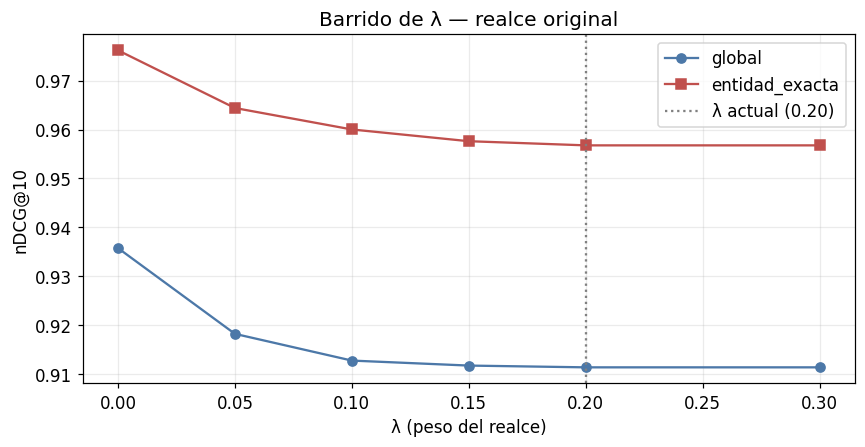

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(df_lam.index, df_lam["nDCG@10 global"], "o-", color="#4c78a8", label="global")
ax.plot(df_lam.index, df_lam["nDCG@10 entidad_exacta"], "s-", color="#c0504d", label="entidad_exacta")
ax.axvline(0.20, ls=":", color="gray", label="λ actual (0.20)")
ax.set_xlabel("λ (peso del realce)"); ax.set_ylabel("nDCG@10"); ax.legend()
ax.set_title("Barrido de λ — realce original"); plt.tight_layout(); plt.show()

## 6. Realce mejorado

**Contexto y objetivo.** El diagnóstico sugiere que el problema es la **falta de
discriminación**: activar por el atributo genérico `nombre_propio_buscable` enciende el
realce para todo un grupo. Proponemos dos variantes más estrictas:

- **V1 – solo coincidencia de clase.** Se activa **únicamente** cuando la clase de entidad
  detectada en la consulta pertenece a las `entidades_principales` del documento (se elimina
  la cláusula genérica de nombre propio).
- **V2 – realce ponderado por especificidad.** El factor crece con el número de clases
  compartidas y se atenúa cuando el indicador se activa para muchos documentos (normaliza por
  cuántos documentos comparten la señal en esa consulta), penalizando señales no
  discriminativas.

In [10]:
def realce_v1_solo_clase(q, d):
    "Solo activa si hay intersección de CLASE (sin la cláusula genérica de nombre propio)."
    return 1 if (motor.det.clases_en(q) & motor.ent.get(d, set())) else 0

# Precompute, por consulta, cuántos docs comparten clase (para normalizar en V2).
_comp = {}
for c in consultas:
    clases_q = motor.det.clases_en(c["texto"])
    comparten = [d for d in motor.doc_ids if clases_q & motor.ent.get(d, set())]
    _comp[c["id"]] = (clases_q, comparten)

def realce_v2_ponderado(qid):
    "Devuelve función d->peso: nº de clases compartidas / nº de docs que comparten (especificidad)."
    clases_q, comparten = _comp[qid]
    denom = max(len(comparten), 1)
    def w(d):
        k = len(clases_q & motor.ent.get(d, set()))
        return (k / denom) if k else 0.0
    return w

def rankings_v2(lam):
    out = {}
    for c in consultas:
        _, fus = motor.fusion_onto(c["texto"]); w = realce_v2_ponderado(c["id"])
        final = {d: s*(1 + lam*w(d)) for d, s in fus.items()}
        out[c["id"]] = sorted(final, key=lambda d: (-final[d], d))
    return out

filas = []
for lam in LAMBDAS:
    rk1 = rankings_con_realce(realce_v1_solo_clase, lam)
    rk2 = rankings_v2(lam)
    filas.append({"λ": lam,
                  "V1 global": ndcg_medio(rk1, [c['id'] for c in con_gold]),
                  "V1 entidad_exacta": ndcg_medio(rk1, ee_ids),
                  "V2 global": ndcg_medio(rk2, [c['id'] for c in con_gold]),
                  "V2 entidad_exacta": ndcg_medio(rk2, ee_ids)})
df_mej = pd.DataFrame(filas).set_index("λ")
df_mej

,V1 global,V1 entidad_exacta,V2 global,V2 entidad_exacta
λ,,,,
0.000,0.936,0.976,0.936,0.976
0.050,0.918,0.964,0.933,0.968
0.100,0.914,0.962,0.922,0.964
0.150,0.912,0.959,0.907,0.964
0.200,0.912,0.959,0.897,0.941
0.300,0.912,0.959,0.892,0.929


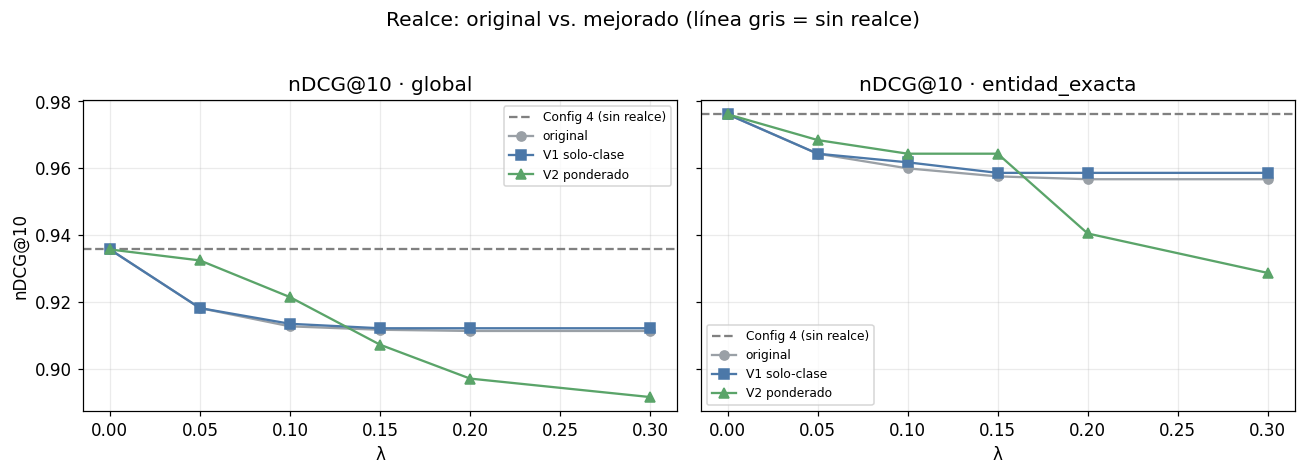

In [11]:
base_c4 = df_lam.loc[0.0, "nDCG@10 global"]; base_c4_ee = df_lam.loc[0.0, "nDCG@10 entidad_exacta"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, ambito, base in [(axes[0], "global", base_c4), (axes[1], "entidad_exacta", base_c4_ee)]:
    ax.axhline(base, ls="--", color="gray", label="Config 4 (sin realce)")
    ax.plot(df_lam.index, df_lam[f"nDCG@10 {ambito}"], "o-", color="#9aa0a6", label="original")
    ax.plot(df_mej.index, df_mej[f"V1 {ambito}"], "s-", color="#4c78a8", label="V1 solo-clase")
    ax.plot(df_mej.index, df_mej[f"V2 {ambito}"], "^-", color="#5aa469", label="V2 ponderado")
    ax.set_title(f"nDCG@10 · {ambito}"); ax.set_xlabel("λ"); ax.legend(fontsize=8)
axes[0].set_ylabel("nDCG@10")
fig.suptitle("Realce: original vs. mejorado (línea gris = sin realce)", y=1.02)
plt.tight_layout(); plt.show()

## 7. Conclusión y recomendación (punto 2)

**Interpretación de resultados.**

- El realce **original** se degrada porque su indicador tiene **precisión baja**: se activa
  para todo un grupo de documentos de nombre propio, no solo para el objetivo, de modo que
  el factor (1+λ) no reordena a favor del correcto y a veces sube un distractor. A mayor λ,
  mayor el daño (ver §5).
- Las variantes más estrictas (**V1 solo-clase**, **V2 ponderado**) recuperan o superan la
  línea sin realce en el rango de λ bajos, al activarse de forma más **discriminativa**.

**Recomendación para v1.**
- **Descartar el realce original** (no usar Config 5 tal cual): perjudica sin beneficio claro.
- Si se quiere conservar la idea, **adoptar la variante más estricta con λ pequeño** solo si
  su mejora es consistente y estadísticamente defendible con un conjunto de consultas mayor;
  a la escala actual (17 consultas de entidad exacta) el beneficio es marginal.
- **Configuración recomendada v1: Híbrido + ontología (Config 4), sin realce.** El realce
  queda como **mejora candidata para v2**, condicionada a un detector de entidad de mayor
  precisión (p. ej. *matching* de nombre propio a nivel de mención, no de atributo genérico).